### Einlesen der Bilder

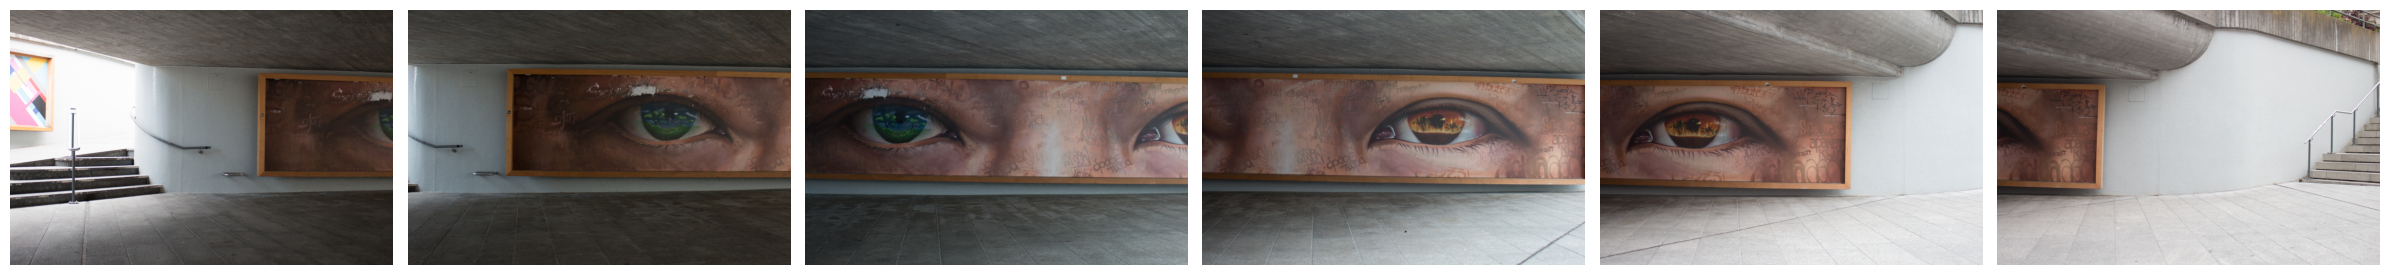

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import cv2
import sift

setname = "Set2" 
images = []
images_g = []

def preprocess_for_sift(img_rgb):
    # RGB uint8
    img_u8 = (np.clip(img_rgb, 0, 1) * 255).astype(np.uint8)

    # --- 1. CLAHE (Kontrast lokal verbessern) ---
    gray = cv2.cvtColor(img_u8, cv2.COLOR_RGB2GRAY)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray = clahe.apply(gray)

    # --- 2. leichte Schärfung (Unsharp Mask) ---
    blur = cv2.GaussianBlur(gray, (0, 0), 1.0)
    sharp = cv2.addWeighted(gray, 1.5, blur, -0.5, 0)

    return sharp

for file in Path("Bilder").glob(f"{setname}*"):
    image = plt.imread(file)
    image = image.astype(float)
    image = image / 255
    images.append(image)

    image_g = preprocess_for_sift(image)
    images_g.append(image_g)

fig, axes = plt.subplots(1, len(images), figsize=(4 * len(images), 4))

# Falls nur ein Bild vorhanden ist:
if len(images) == 1:
    axes = [axes]

for ax, img in zip(axes, images):
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

### Bestimmung der Homographien der Bildpaare (SIFT + RANSAC)

1162 key points detected.
790 key points detected.
1575 key points detected.
1598 key points detected.
1437 key points detected.
1354 key points detected.


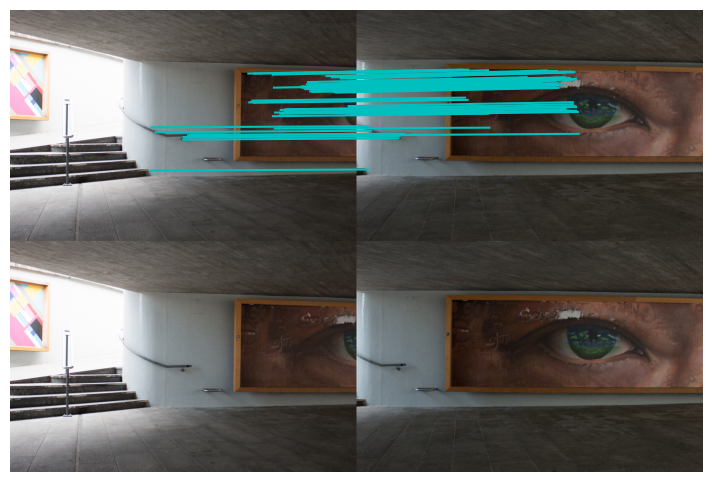

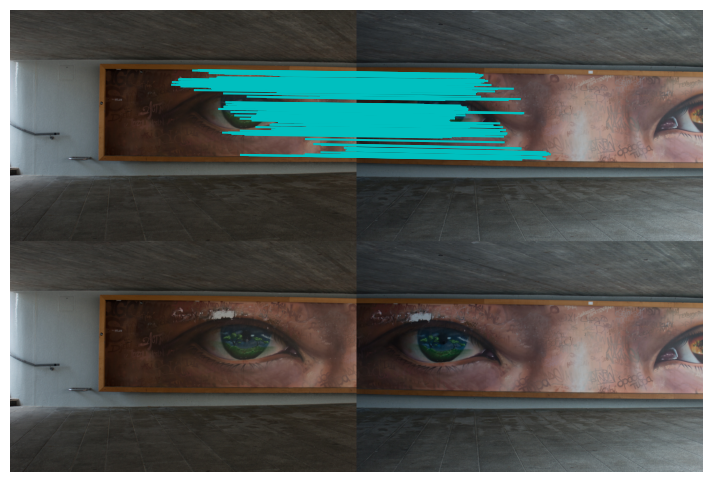

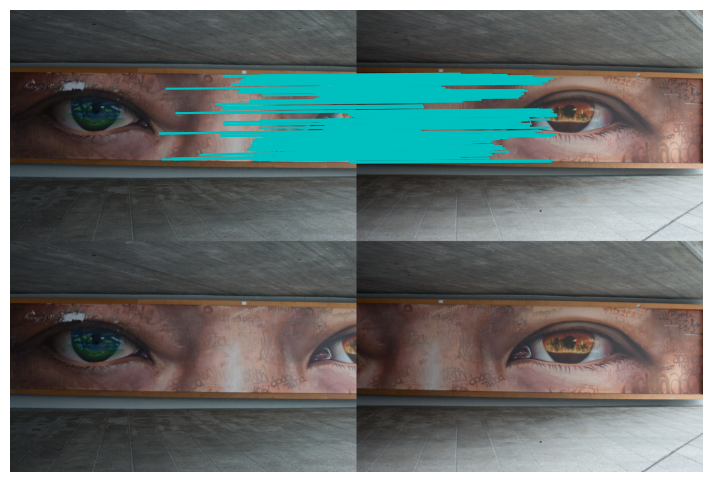

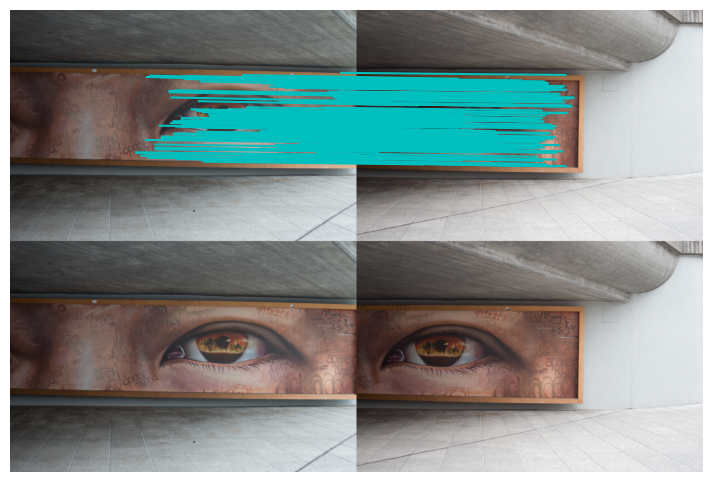

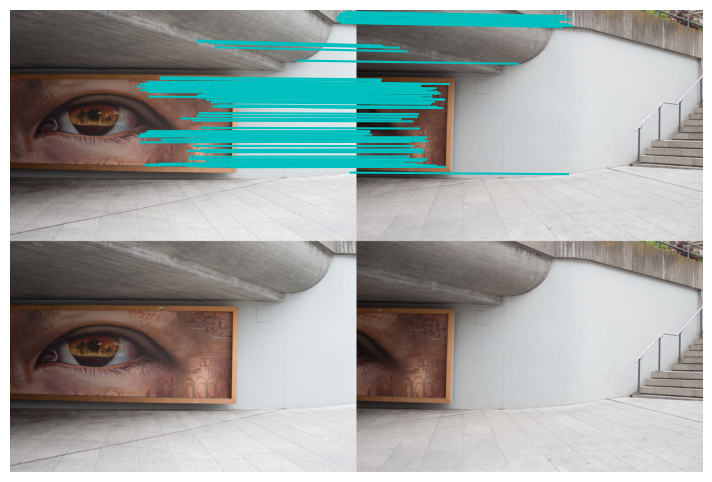

In [47]:
# Keypoints und Deskriptoren
location_lists = []
descriptor_lists = []

for img in images_g:
    locations, descriptors = sift.detect_and_compute(img)
    location_lists.append(locations)
    descriptor_lists.append(descriptors)

# Matching benachbarter Bilder
matches = []

for i in range(len(images_g) - 1):
    matches.append(
        sift.match_twosided(
            descriptor_lists[i],
            descriptor_lists[i + 1]
        )
    )

for i in range(len(images)-1):
    plt.figure(figsize=(12,6))
    sift.plot_matches(
        images[i],
        images[i+1],
        location_lists[i],
        location_lists[i+1],
        matches[i],
        True
    )
    plt.show()

In [48]:
def correspondences_from_matches(location_list_img1,
                                 location_list_img2,
                                 matches):

    bi = []
    bj = []

    for i in range(len(matches)):

        j = matches[i]

        # In this SIFT implementation: 0 means no match
        if j > 0:
            x1, y1 = location_list_img1[i, 0], location_list_img1[i, 1]
            x2, y2 = location_list_img2[int(j), 0], location_list_img2[int(j), 1]

            bi.append([x1, y1])
            bj.append([x2, y2])

    return np.array(bi, dtype=float), np.array(bj, dtype=float)

In [49]:
correspondences = [
    correspondences_from_matches(
        location_lists[i],
        location_lists[i + 1],
        matches[i]
    )
    for i in range(len(matches))
]

for i, (bi, bj) in enumerate(correspondences, start=1):
    print(f"Number of SIFT correspondences image {i} and {i+1}: {len(bi)}")

Number of SIFT correspondences image 1 and 2: 87
Number of SIFT correspondences image 2 and 3: 211
Number of SIFT correspondences image 3 and 4: 229
Number of SIFT correspondences image 4 and 5: 362
Number of SIFT correspondences image 5 and 6: 150


### Anwendung RANSAC

#### Definition der Hilfsfunktionen

In [50]:
def compute_homography(bi, bj):
    M = []

    for i in range(len(bi)):
        x, y = bi[i]
        u, v = bj[i]

        M.append([x, y, 1, 0, 0, 0, -(u*x), -(u*y), -u])
        M.append([0, 0, 0, x, y, 1, -(v*x), -(v*y), -v])

    M = np.array(M)

    # SVD von M
    U, S, Vt = np.linalg.svd(M)

    # Lösung ist der Singulärvektor zum kleinsten Singulärwert
    h = Vt[-1]

    H = np.array([
        [h[0], h[1], h[2]],
        [h[3], h[4], h[5]],
        [h[6], h[7], h[8]]
    ])

    # Normieren, sodass H[2,2] = 1
    H = H / H[2, 2]

    return H

def transform_points(points, H, eps=1e-10):

    transformed = []

    for x, y in points:

        q = H @ np.array([x, y, 1.0])

        if abs(q[2]) < eps:
            transformed.append([np.nan, np.nan])
            continue

        q /= q[2]
        transformed.append([q[0], q[1]])

    return np.array(transformed)

def normalize_points(points):

    mean_x = np.mean(points[:,0])
    mean_y = np.mean(points[:,1])

    std_x = np.std(points[:,0])
    std_y = np.std(points[:,1])

    T = np.array([
        [1/std_x, 0, -mean_x/std_x],
        [0, 1/std_y, -mean_y/std_y],
        [0, 0, 1]
    ])

    points_norm = transform_points(points, T)

    return points_norm, T

def compute_homography_normalized(bi, bj):

    bi_norm, T = normalize_points(bi)
    bj_norm, T_prime = normalize_points(bj)

    H_norm = compute_homography(bi_norm, bj_norm)

    H = np.linalg.inv(T_prime) @ H_norm @ T

    H = H / H[2,2]

    return H

def mean_error(points_true, points_estimated):

    distances = []

    for p_true, p_est in zip(points_true, points_estimated):

        d = np.sqrt(
            (p_true[0] - p_est[0])**2 +
            (p_true[1] - p_est[1])**2
        )

        distances.append(d)

    return np.mean(distances), np.array(distances)

#### Definition von RANSAC

In [51]:
def ransac_homography_normalized(bi, bj, iterations=1000, threshold=50):
    """
    RANSAC für Homographie-Schätzung mit normierter DLT.

    bi: Punkte in Bild 1
    bj: korrespondierende Punkte in Bild 2
    threshold: maximaler Fehler für Inlier
    """

    n = len(bi)

    best_H = None
    best_inliers = None
    best_error = np.inf

    indices = np.arange(n)

    for k in range(iterations):

        # 1. Zufällig 4 Korrespondenzen auswählen
        sample_idx = np.random.choice(indices, 4, replace=False)

        bi_sample = bi[sample_idx]
        bj_sample = bj[sample_idx]

        # 2. Homographie mit normierter DLT berechnen
        try:
            H = compute_homography_normalized(bi_sample, bj_sample)
        except:
            continue

        # 3. Alle Punkte transformieren
        bj_estimated = transform_points(bi, H)

        # 4. Fehler berechnen
        errors = np.sqrt(
            (bj[:,0] - bj_estimated[:,0])**2 +
            (bj[:,1] - bj_estimated[:,1])**2
        )

        # 5. Consensus set bestimmen
        inliers = errors < threshold

        num_inliers = np.sum(inliers)

        if num_inliers > 0:
            mean_inlier_error = np.mean(errors[inliers])
        else:
            mean_inlier_error = np.inf

        # 6. Bestes Modell speichern
        if best_inliers is None:
            update = True
        else:
            update = (
                num_inliers > np.sum(best_inliers)
                or
                (num_inliers == np.sum(best_inliers)
                 and mean_inlier_error < best_error)
            )

        if update:
            best_H = H
            best_inliers = inliers
            best_error = mean_inlier_error

    # Finale Homographie nochmal mit allen Inliern berechnen
    if best_inliers is not None and np.sum(best_inliers) >= 4:
        best_H = compute_homography_normalized(
            bi[best_inliers],
            bj[best_inliers]
        )

        bj_estimated = transform_points(bi[best_inliers], best_H)

        best_error, _ = mean_error(
            bj[best_inliers],
            bj_estimated
        )

    return best_H, best_inliers, best_error

In [52]:
ransac_results = [
    ransac_homography_normalized(
        bi,
        bj,
        iterations=1000,
        threshold=10
    )
    for bi, bj in correspondences
]

for i, (_, inliers, mse) in enumerate(ransac_results, start=1):
    print(f"Bild {i} und {i+1}:")
    print("- Anzahl Inlier:", np.sum(inliers))
    print("- Mittlerer quadratischer Fehler:", mse)
    print()

# Store homographies
Hs = []
for r in ransac_results:
    Hs.append(r[0])

Bild 1 und 2:
- Anzahl Inlier: 87
- Mittlerer quadratischer Fehler: 1.246054435581205

Bild 2 und 3:
- Anzahl Inlier: 211
- Mittlerer quadratischer Fehler: 0.44893881214132253

Bild 3 und 4:
- Anzahl Inlier: 229
- Mittlerer quadratischer Fehler: 0.39150529042017734

Bild 4 und 5:
- Anzahl Inlier: 362
- Mittlerer quadratischer Fehler: 0.5605270616100676

Bild 5 und 6:
- Anzahl Inlier: 146
- Mittlerer quadratischer Fehler: 1.1767439007379665



### Testen der Korrespondenzen

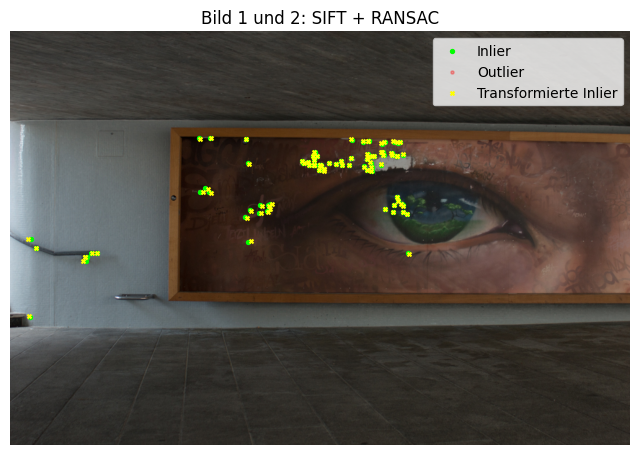

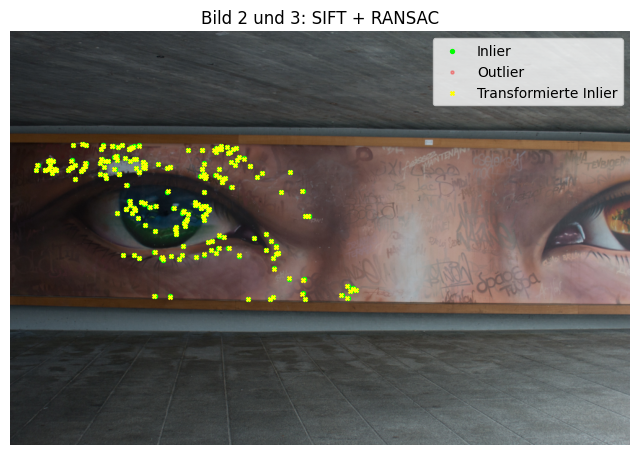

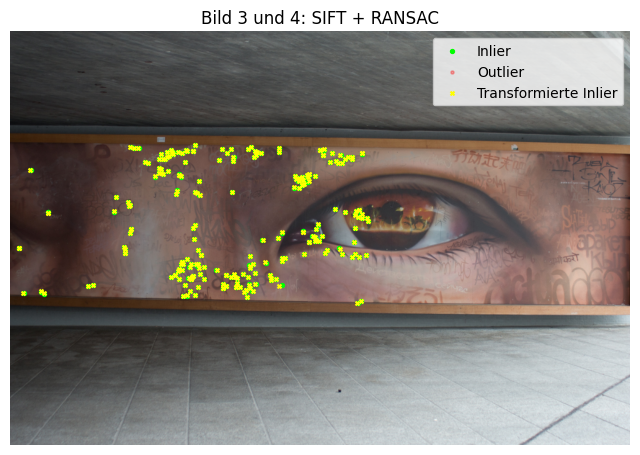

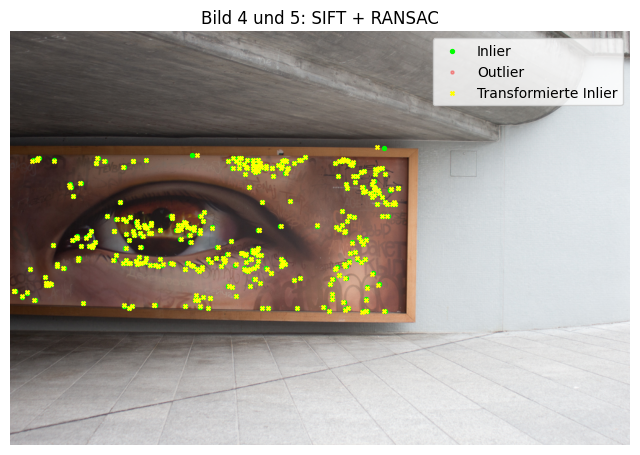

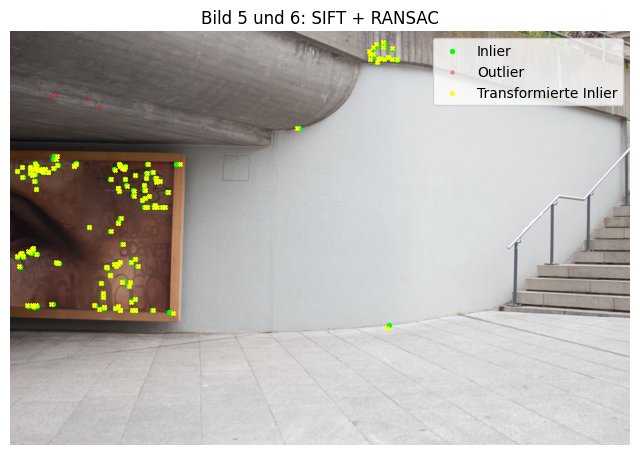

In [53]:
for i, ((bi, bj), (H, inliers, _)) in enumerate(zip(correspondences, ransac_results), start=1):

    bj_est = transform_points(bi, H)

    plt.figure(figsize=(8,6))
    plt.imshow(images[i])

    plt.scatter(
        bj[inliers, 0],
        bj[inliers, 1],
        c="lime",
        s=8,
        label="Inlier"
    )

    plt.scatter(
        bj[~inliers, 0],
        bj[~inliers, 1],
        c="red",
        s=5,
        alpha=0.3,
        label="Outlier"
    )

    plt.scatter(
        bj_est[inliers, 0],
        bj_est[inliers, 1],
        c="yellow",
        marker="x",
        s=8,
        label="Transformierte Inlier"
    )

    plt.legend()
    plt.axis("off")
    plt.title(f"Bild {i} und {i+1}: SIFT + RANSAC")
    plt.show()

### Ermittlung der Panorama-Größe

In [54]:
def transformed_corners(image, H):

    h, w = image.shape[:2]

    corners = np.array([
        [0, 0],
        [w, 0],
        [w, h],
        [0, h]
    ], dtype=float)

    return transform_points(corners, H)

In [55]:
H1 = Hs[4] @ Hs[3] @ Hs[2] @ Hs[1] @ Hs[0]
H2 = Hs[4] @ Hs[3] @ Hs[2] @ Hs[1]
H3 = Hs[4] @ Hs[3] @ Hs[2]
H4 = Hs[4] @ Hs[3]
H5 = Hs[4]
H6 = np.eye(3)

Hs_global = [H1, H2, H3, H4, H5, H6]

# Eckpunkte transformieren und sammeln
all_corners = np.concatenate(
    [transformed_corners(img, H) for img, H in zip(images, Hs_global)],
    axis=0
)

print(all_corners)

xmin, ymin = np.min(all_corners, axis=0)
xmax, ymax = np.max(all_corners, axis=0)

PAN_WIDTH  = int(np.ceil(xmax - xmin))
PAN_HEIGHT = int(np.ceil(ymax - ymin))

T = np.array([
    [1, 0, -xmin],
    [0, 1, -ymin],
    [0, 0, 1]
])

# verschobene Homographien

Hs_shifted = [T @ H for H in Hs_global]

[[-1181.75904893   131.85485261]
 [ -724.11827507    41.88373823]
 [ -739.54392482   601.82300985]
 [-1187.44874757   488.33685916]
 [-1051.723379     107.44619512]
 [ -476.6883899     44.78998586]
 [ -496.48941019   629.31777832]
 [-1065.56985435   526.05902598]
 [ -855.46191036    75.36446097]
 [ -127.74005382    20.55732002]
 [ -148.45625922   646.71368131]
 [ -864.40968538   562.63241707]
 [ -596.13050247    53.82621335]
 [  273.83309407    11.72823989]
 [  256.92847032   678.63695475]
 [ -606.15877393   607.89450419]
 [ -321.29781501    18.60959028]
 [  634.1544304     10.94527435]
 [  620.67537245   675.28428202]
 [ -332.57924005   634.90992718]
 [    0.             0.        ]
 [ 1000.             0.        ]
 [ 1000.           667.        ]
 [    0.           667.        ]]


### Projektive Entzerrung + Berechnung der Gewichte

In [56]:
def compute_weights(height, width):

    weights = np.zeros((height, width), dtype=np.float32)

    for y in range(height):
        for x in range(width):

            wx = 1 - (2 / width) * abs(x - width / 2)
            wy = 1 - (2 / height) * abs(y - height / 2)

            weights[y, x] = wx * wy

    return weights


def image_rectification(image, H, out_h, out_w):

    H_inv = np.linalg.inv(H)

    # Graubild oder RGB?
    if len(image.shape) == 2:
        rectified = np.zeros((out_h, out_w),
                             dtype=image.dtype)
    else:
        rectified = np.zeros((out_h, out_w, image.shape[2]),
                             dtype=image.dtype)

    for y_ref in range(out_h):
        for x_ref in range(out_w):

            p_ref = np.array([x_ref, y_ref, 1])

            p_img = H_inv @ p_ref
            p_img /= p_img[2]

            x = p_img[0]
            y = p_img[1]

            x_n = int(np.round(x))
            y_n = int(np.round(y))

            if (0 <= x_n < image.shape[1] and
                0 <= y_n < image.shape[0]):

                rectified[y_ref, x_ref] = image[y_n, x_n]

    return rectified

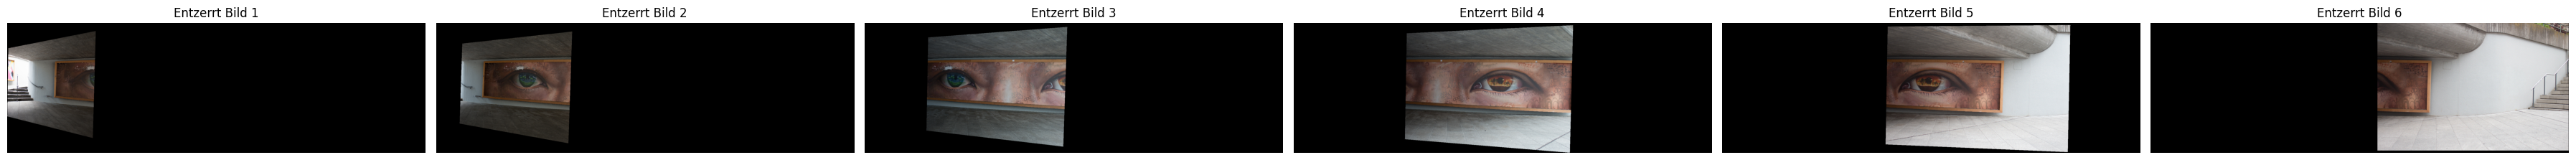

In [57]:
weights_all = []
weights_rect_all = []
rectified_images = []

for img, H in zip(images, Hs_shifted):

    h, w = img.shape[:2]

    # Gewichte
    weights = compute_weights(h, w)
    weights_all.append(weights)

    # Bild entzerren
    rectified = image_rectification(img, H, PAN_HEIGHT, PAN_WIDTH)
    rectified_images.append(rectified)

    # Gewichte entzerren
    weights_rect = image_rectification(weights, H, PAN_HEIGHT, PAN_WIDTH)
    weights_rect_all.append(weights_rect)


fig, axes = plt.subplots(1, len(rectified_images), figsize=(6 * len(rectified_images), 7))

# Falls nur 1 Bild
if len(rectified_images) == 1:
    axes = [axes]

for idx, rectified in enumerate(rectified_images):

    axes[idx].imshow(rectified)

    axes[idx].set_title(
        f"Entzerrt Bild {idx+1}"
    )

    axes[idx].axis("off")

plt.tight_layout()
plt.show()

### Anwendung Multiband-Blending

In [58]:
def blend_images_mb(img1,
                    img2,
                    weights1,
                    weights2,
                    mode="average"):

    h, w = img1.shape[:2]
    output = np.zeros_like(img1, dtype=np.float32)

    for y in range(h):
        for x in range(w):

            p1 = img1[y, x].astype(np.float32)
            p2 = img2[y, x].astype(np.float32)

            w1 = weights1[y, x]
            w2 = weights2[y, x]

            # Hochpassbilder können auch negative Werte haben, daher max mit 0
            w1 = max(w1, 0.0)
            w2 = max(w2, 0.0)

            denom = w1 + w2 + 1e-8

            if mode == "average":
                output[y, x] = (w1 * p1 + w2 * p2) / denom

            elif mode == "max":
                output[y, x] = p1 if w1 > w2 else p2

    return output

def lowpass(image, ksize=21, sigma=5):

    return cv2.GaussianBlur(
        image.astype(np.float32),
        (ksize, ksize),
        sigma
    )

def highpass(image, low):

    high = image.astype(np.float32) - low

    return high

def multiband_blend(
    img1,
    img2,
    weights1,
    weights2,
    ksize=21,
    sigma=5
):

    low1 = lowpass(img1, ksize, sigma)
    low2 = lowpass(img2, ksize, sigma)

    high1 = highpass(img1, low1)
    high2 = highpass(img2, low2)

    low_blend = blend_images_mb(low1, low2, weights1, weights2, mode="average")
    high_blend = blend_images_mb(high1, high2, weights1, weights2, mode="max")

    result = low_blend + high_blend
    # Hier nicht uint8, da Hochpassbilder auch negative Werte haben können
    return np.clip(result, 0, 255)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0639338].


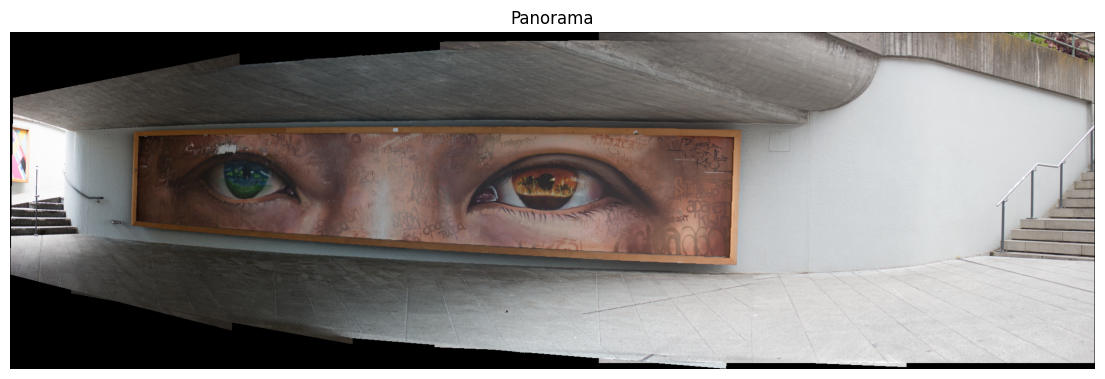

In [59]:
panorama_mb = rectified_images[0]
panorama_weights_mb = weights_rect_all[0]
for i in range(1, len(rectified_images)):

    panorama_mb = multiband_blend(
        panorama_mb,
        rectified_images[i],
        panorama_weights_mb,
        weights_rect_all[i],
        ksize=21,
        sigma=5
    )

    panorama_weights_mb = np.maximum(
        panorama_weights_mb,
        weights_rect_all[i]
    )
    
plt.figure(figsize=(14,8))
plt.imshow(panorama_mb)
plt.axis("off")
plt.title("Panorama")
plt.show()